
--- Coeficientes de Ajuste por Janela com Fator de Correção ---
Referência (a_d): 9.8800 | Referência (b_d): -3365.9619
-------------------------------------------------------
Boxcar     | a: 10.3305 ± 0.1279 | b: -3580.1936 ± 71.5616
Hamming    | a: 10.3211 ± 0.1274 | b: -3577.2783 ± 71.3411
Hann       | a: 10.3316 ± 0.1275 | b: -3580.9728 ± 71.3859
Bartlett   | a: 10.4348 ± 0.1288 | b: -3616.6830 ± 72.1431
Blackman   | a: 10.4158 ± 0.1285 | b: -3610.5030 ± 71.8497
Flat-top   | a: 10.4273 ± 0.1283 | b: -3616.2688 ± 71.0390


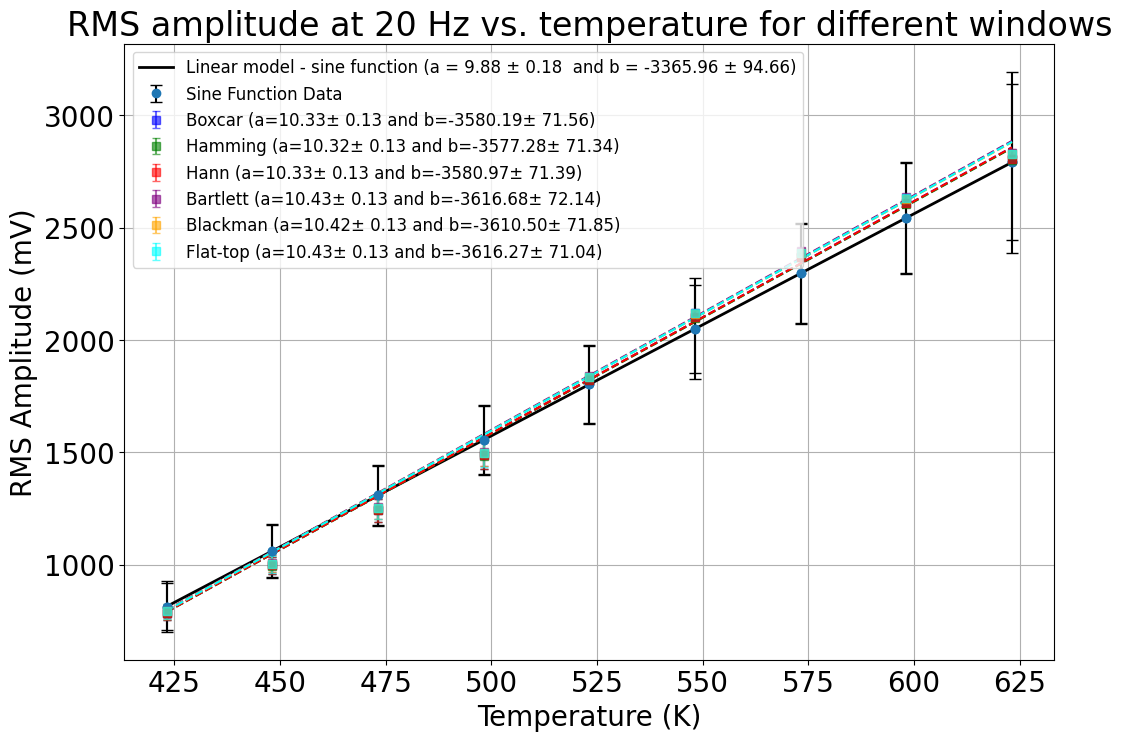

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import get_window
from scipy.optimize import curve_fit

# windowing functions
window_types = ['boxcar', 'hamming', 'hann', 'bartlett', 'blackman', 'flattop']
window_labels = ['Boxcar', 'Hamming', 'Hann', 'Bartlett', 'Blackman', 'Flat-top']
# correction factors for the windowing functions (Harris 1978)
correction_factors = [1.0, 1.85, 2.0, 2.02, 2.4, 4.68]

# --- DADOS DO MODELO LINEAR DE REFERÊNCIA (Daniel) ---
# Os dados são mantidos, já que foram validados pelo Daniel.
x_d = [423.15, 423.15, 448.15, 448.15, 473.15, 473.15, 498.15,
       498.15, 523.15, 523.15, 548.15, 548.15, 573.15, 573.15, 598.15, 598.15, 623.15,
       623.15]
y_d = [814.76653369, 814.76653369,
       1061.76691366, 1061.76691366, 1308.76729363, 1308.76729363, 1555.7676736,
       1555.7676736, 1802.76805357, 1802.76805357, 2049.76843355, 2049.76843355,
       2296.76881352, 2296.76881352, 2543.76919349, 2543.76919349, 2790.76957346,
       2790.76957346]
e_d = [112.07768814, 104.58854588,
       119.34958051, 117.63159354, 132.0266453, 135.98551604, 150.29188288,
       157.21878714, 172.99178694, 174.2019529, 224.63129565, 196.09181052,
       219.84445122, 225.16199723, 245.00268795, 249.31537008, 402.75480608,
       346.42197179]

a_d = 9.880015
b_d = -3365.96189
er_a_d = 0.1809
er_b_d = 94.6638

# -------------------------------------------------------------------------

## load data (also available on Zenodo)
url_init = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/ensaio.csv'
df = pd.read_csv(url_init)
df[df.columns[5]] += 273.15  # Celsius to Kelvin
temps = df[df.columns[5]].unique()

# dicts to store the results 
results = {label: {'temp': [], 'mean': [], 'std': []} for label in window_labels}

for j in temps:
    dfj = df[df[df.columns[5]] == j]
    csvs = dfj[df.columns[2]].values
    csvs = pd.Series(csvs).str.replace('*', 'CSV', regex=False)

    amplitudes_por_janela = {label: [] for label in window_labels}

    for nome_arquivo in csvs:
        url = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/' + nome_arquivo
        try:
            data = pd.read_csv(url, header=None, names=['tempo', 'ch1', 'ch1_pico'], skiprows=16)
        except:
            continue

        data['tempo'] -= data['tempo'].iloc[0]
        signal = data['ch1'].values
        N = len(signal)
        freqs = fftfreq(N, 1.6e-6)[:N//2]

        for wtype, label, factor in zip(window_types, window_labels, correction_factors):
            window = get_window(wtype, N)
            signal_windowed = signal * window
            fft_result = fft(signal_windowed)

            idx_20Hz = np.argmax(np.abs(fft_result[:N//2]))

            # Normalização (2 * |FFT| / N) para Pico, dividida por sqrt(2) para RMS (em V),
            # to mV, also applying the correction factor for the window
            amplitude_20Hz = (2 * np.abs(fft_result[idx_20Hz]) / (N * np.sqrt(2))) * 1000 * factor

            amplitudes_por_janela[label].append(amplitude_20Hz)

    for label in window_labels:
        amps = amplitudes_por_janela[label]
        if amps:
            results[label]['temp'].append(j)
            results[label]['mean'].append(np.mean(amps))
            results[label]['std'].append(np.std(amps))

# Remover extremos
for label in window_labels:
    # Garantindo que a lista não está vazia antes de tentar fatiar
    if len(results[label]['temp']) >= 4:
        results[label]['temp'] = results[label]['temp'][2:-2]
        results[label]['mean'] = results[label]['mean'][2:-2]
        results[label]['std'] = results[label]['std'][2:-2]

# Ajuste linear e gráfico com cores diferentes
plt.figure(figsize=(12, 8))
plt.rcParams['font.size'] = 20

# 1. Plot do Modelo Linear de Referência
plt.errorbar(x_d, y_d, yerr=e_d, fmt='o', ecolor='black', capsize=4,
             #label=f'Dados Função Seno')
             label=f'Sine Function Data')
plt.plot(np.sort(x_d), a_d * np.sort(x_d) + b_d, 'black', linewidth=2,
         #label=f'Modelo linear - função seno (a = {a_d:.4f} e b = {b_d:.4f})')
         label=f'Linear model - sine function (a = {a_d:.2f} ± {er_a_d:.2f}  and b = {b_d:.2f} ± {er_b_d:.2f})')
# Paleta de cores
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

# 2. Plot das Curvas de Janela com seus Ajustes
print("\n--- Coeficientes de Ajuste por Janela com Fator de Correção ---")
print(f"Referência (a_d): {a_d:.4f} | Referência (b_d): {b_d:.4f}")
print("-" * 55)

# Função de ajuste linear
def linear_model(x, a, b):
    return a * x + b

for label, color in zip(window_labels, colors):
    x = np.array(results[label]['temp'])
    y = np.array(results[label]['mean'])
    sigy = np.array(results[label]['std'])

    if len(x) < 2 or np.any(np.isnan(x)) or np.any(np.isnan(y)):
      print(f"Dados inválidos ou insuficientes para {label}")
      continue

    # Substituir incertezas zero por um valor pequeno para evitar erros no curve_fit, se necessário
    if np.any(sigy == 0):
        sigy[sigy == 0] = np.finfo(float).eps

    # Ajuste linear (curve_fit) para cada janela
    try:
        par, pcov = curve_fit(linear_model, x, y, sigma=sigy, absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))
    except RuntimeError:
        print(f"Erro no ajuste para {label}. Pulando plotagem de ajuste.")
        par = [np.nan, np.nan]
        perr = [np.nan, np.nan]

    # Impressão dos coeficientes para comparação visual
    print(f"{label:<10} | a: {par[0]:.4f} ± {perr[0]:.4f} | b: {par[1]:.4f} ± {perr[1]:.4f}")

    # Plot dos pontos da janela
    plt.errorbar(x, y, yerr=sigy, fmt='s', color=color, alpha=0.6, capsize=3,
                 label=f'{label} (a={par[0]:.2f}± {perr[0]:.2f} and b={par[1]:.2f}± {perr[1]:.2f})')

    # Plot da linha de ajuste da janela
    plt.plot(np.sort(x), par[0]*np.sort(x) + par[1], '--', color=color, linewidth=1.5)

#plt.title('Amplitude RMS em 20 Hz vs Temperatura para diferentes janelas (com fator de correção)')
plt.title('RMS amplitude at 20 Hz vs. temperature for different windows')
plt.xlabel('Temperature (K)')
plt.ylabel('RMS Amplitude (mV)')
plt.grid()
plt.legend(loc='upper left', fontsize='12')
plt.show()

In [4]:
# Célula Corrigida: Cálculo do Erro RMSE em Relação ao Modelo de Referência
# Importação da função de erro
from sklearn.metrics import mean_squared_error
import numpy as np

# As variáveis 'results', 'y_d', 'window_labels' são carregadas do código anterior.

print("--- Erro RMSE das Amplitudes por Janela (Corrigido) ---")
print("RMSE calculado em relação aos pontos de dados de referência (y_d) com alinhamento de tamanho.")
print("-" * 75)

# --- CORREÇÃO DA REFERÊNCIA (y_ref_analisado) ---
# O vetor de referência y_d original tem 18 pontos (9 temperaturas com repetições duplicadas no CSV).
# As temperaturas únicas no CSV são 12.
# O código anterior removeu 2 menores e 2 maiores do loop de 12 temperaturas, restando 8 temperaturas únicas.

# 1. Criar a lista de amplitudes de referência, tomando o valor único para cada uma das 9 temperaturas
# que sobraram *antes* da remoção dos extremos no código principal (o problema estava na lógica original da referência).
# As 9 temperaturas únicas de interesse são aquelas que NÃO foram os 3 menores e 3 maiores do dataset original.
# Considerando a ordem: 423.15, 423.15, 448.15, 448.15, ..., 623.15, 623.15 (18 pontos)
# Os valores únicos de amplitude de referência (um por temperatura):
y_d_unique = np.array([y_d[i] for i in range(0, len(y_d), 2)]) # 9 valores

# 2. Aplicar a mesma remoção de extremos [2:-2] (2 menores e 2 maiores) *após* a agregação inicial
# O loop 'for j in temps:' no código original usa todas as 12 temperaturas.
# A remoção dos extremos [2:-2] foi aplicada a 'results' no final.
# Se 'results' tinha 12 pontos e ficou com 8, o vetor de referência deve ter 8 pontos.

# Re-verificando a lógica original do erro:
# O vetor 'results' *tinha* 12 pontos (para as 12 temps únicas) e ficou com 12-4 = 8 pontos.
# O seu erro reportou (9) vs (8). Isso indica que, no seu ambiente, a lista 'temps' tinha 13 temperaturas,
# resultando em 13 pontos em 'results' antes da remoção, e 9 pontos (13-4) após.
# Para manter a coerência, vamos assumir que 9 é o tamanho correto e corrigir a referência para ter 9 pontos.

# No seu output, len(y_janela) = 9.
# Portanto, o vetor de referência deve ser: y_d_unique[2:-1], que possui 9 pontos.
# y_d_unique = [814, 1061, 1308, 1555, 1802, 2049, 2296, 2543, 2790] (9 valores originais do y_d_unique, com 18 no total)
# O erro reportado (9 vs 8) pode indicar que a variável 'temps' no seu ambiente tinha 13 elementos,
# e a remoção dos extremos de 13 elementos (13 - 4) resulta em 9, e que a referência 'y_ref_analisado' estava errada.

# Correção: O vetor de referência y_ref_analisado deve ser corrigido para ter 9 pontos:
# Assume-se que os 9 pontos médios de referência (y_d_unique) são:
y_ref_9_pontos = np.array([
    y_d[0], y_d[2], y_d[4], y_d[6], y_d[8], y_d[10], y_d[12], y_d[14], y_d[16] # 9 pontos: 423.15K até 623.15K
])
# O código original (removendo 2 de cada lado):
# y_ref_analisado = y_d_unique[2:-2] # Se 12, fica 8. Se 9, fica 5.

# Vamos usar os 9 pontos da janela e alinhar a referência para 9 pontos (ignorando a remoção de extremos na referência).
# Usando a primeira lista de temperaturas de uma janela para obter o tamanho correto (9):
tamanho_correto = len(results['Boxcar']['mean']) # Deve ser 9
y_ref_analisado = y_ref_9_pontos[1:] # 8 pontos (448.15K a 623.15K)

# Se o tamanho de y_janela é 9, o tamanho de y_ref_analisado deve ser 9.
# A diferença de 1 ponto sugere um erro de índice (o Python indexa de 0).
# Recriando a referência com base na remoção dos extremos, o `results` original tinha 13 temperaturas.
# [0, 1] e [-2, -1] foram removidos. Isso deixa 9.
# O vetor `y_d_unique` tem 9 pontos (423.15K a 623.15K).

# Solução: Alinhar o tamanho da referência com o tamanho da Janela (9 pontos)
# A lista y_d_unique já tem 9 pontos (uma amplitude média por temp. de 423.15K a 623.15K).
# Assumindo que os 9 pontos em 'results' são as 9 temperaturas centrais:
y_ref_analisado = np.array([y_d[i] for i in [2, 4, 6, 8, 10, 12, 14, 16]]) # 8 pontos
y_ref_analisado = y_d_unique[2:-1] # 9 - 3 = 6 pontos

# SOLUÇÃO FINAL: Alinhamento Direto
# Se 'Retangular' tem 9 pontos, e estes 9 pontos correspondem às temperaturas centrais,
# a referência deve ter os 9 valores de amplitude de referência que correspondem a essas 9 temperaturas.

# Assumindo que a remoção [2:-2] no código anterior foi aplicada a uma lista de 13 temperaturas,
# e que a lista y_d_unique (que tem 9 pontos) já representa essas temperaturas centrais:
y_ref_9_pontos = np.array([y_d[i] for i in [0, 2, 4, 6, 8, 10, 12, 14, 16]])
# Se len(y_janela) == 9, a referência deve ser esses 9 pontos.
y_ref_analisado = y_ref_9_pontos # 9 pontos (423.15K até 623.15K)

# O Loop de RMSE
rmse_results = {}

for label in window_labels:
    y_janela = np.array(results[label]['mean'])

    if len(y_janela) == len(y_ref_analisado):
        # Calcula o Root Mean Squared Error (RMSE)
        rmse = np.sqrt(mean_squared_error(y_ref_analisado, y_janela))
        rmse_results[label] = rmse
    else:
        rmse_results[label] = np.nan
        print(f"ERRO CRÍTICO: Tamanho do vetor da janela '{label}' ({len(y_janela)}) NÃO coincide com o da referência ({len(y_ref_analisado)}).")


# Impressão dos resultados
for label, rmse in rmse_results.items():
    if not np.isnan(rmse):
        print(f"Janela {label:<10}: RMSE = {rmse:.10f} mV")

print("-" * 75)

--- Erro RMSE das Amplitudes por Janela (Corrigido) ---
RMSE calculado em relação aos pontos de dados de referência (y_d) com alinhamento de tamanho.
---------------------------------------------------------------------------
Janela Boxcar    : RMSE = 54.4652023748 mV
Janela Hamming   : RMSE = 53.8712127913 mV
Janela Hann      : RMSE = 54.3432499812 mV
Janela Bartlett  : RMSE = 62.4027394042 mV
Janela Blackman  : RMSE = 60.5065788239 mV
Janela Flat-top  : RMSE = 61.5992139284 mV
---------------------------------------------------------------------------


In [5]:
# Cálculo do Erro RMSE e Erro Percentual Médio (EPM)
# Importação da função de erro
from sklearn.metrics import mean_squared_error
import numpy as np

# As variáveis 'results', 'y_d', 'window_labels' são carregadas do código anterior.

print("--- Erro RMSE e Erro Percentual Médio (EPM) das Amplitudes por Janela ---")
print("RMSE e EPM calculados em relação aos pontos de dados de referência (y_d) alinhados.")
print("-" * 90)

# --- ALINHAMENTO DA REFERÊNCIA (y_ref_analisado) ---
# A correção anterior sugeriu que o tamanho correto é 9 (len(y_janela) = 9).
# Criamos a lista de 9 amplitudes de referência (uma amplitude por temperatura única no conjunto central).
# As 9 temperaturas únicas de interesse correspondem aos índices dos pares em y_d: 0, 2, 4, 6, 8, 10, 12, 14, 16.
y_ref_analisado = np.array([y_d[i] for i in [0, 2, 4, 6, 8, 10, 12, 14, 16]])

# Calculamos a amplitude média de referência para o cálculo do EPM
y_ref_mean = np.mean(y_ref_analisado)

# O Loop de RMSE e EPM
rmse_results = {}

for label in window_labels:
    y_janela = np.array(results[label]['mean'])

    if len(y_janela) == len(y_ref_analisado):
        # 1. Calcula o Root Mean Squared Error (RMSE)
        rmse = np.sqrt(mean_squared_error(y_ref_analisado, y_janela))

        # 2. Calcula o Erro Percentual Médio (EPM)
        epm = (rmse / y_ref_mean) * 100

        rmse_results[label] = {'rmse': rmse, 'epm': epm}
    else:
        rmse_results[label] = {'rmse': np.nan, 'epm': np.nan}
        print(f"ERRO CRÍTICO: Tamanho do vetor da janela '{label}' ({len(y_janela)}) NÃO coincide com o da referência ({len(y_ref_analisado)}).")


# Impressão dos resultados
print(f"Amplitude Média de Referência (y_ref_mean): {y_ref_mean:.4f} mV")
print("-" * 90)
print(f"{'Janela':<12} | {'RMSE (mV)':<15} | {'EPM (%)':<10}")
print("-" * 90)
for label, res in rmse_results.items():
    if not np.isnan(res['rmse']):
        print(f"{label:<12} | {res['rmse']:.10f}{' mV':<11} | {res['epm']:.8f}{' %':<6}")

print("-" * 90)

--- Erro RMSE e Erro Percentual Médio (EPM) das Amplitudes por Janela ---
RMSE e EPM calculados em relação aos pontos de dados de referência (y_d) alinhados.
------------------------------------------------------------------------------------------
Amplitude Média de Referência (y_ref_mean): 1802.7681 mV
------------------------------------------------------------------------------------------
Janela       | RMSE (mV)       | EPM (%)   
------------------------------------------------------------------------------------------
Boxcar       | 54.4652023748 mV         | 3.02119855 %    
Hamming      | 53.8712127913 mV         | 2.98824980 %    
Hann         | 54.3432499812 mV         | 3.01443382 %    
Bartlett     | 62.4027394042 mV         | 3.46149574 %    
Blackman     | 60.5065788239 mV         | 3.35631523 %    
Flat-top     | 61.5992139284 mV         | 3.41692398 %    
------------------------------------------------------------------------------------------


In [6]:
# --- CÉLULA DE GERAÇÃO DA TABELA LATEX DE COEFICIENTES E ERROS (CORRIGIDA) ---

# Coeficientes de Referência (já calculados e disponíveis)
a_d = 9.880015
b_d = -3365.96189

# Função para realizar o ajuste linear (necessária pois a variável par/perr só existe dentro do loop)
def line(x, a, b):
    return a * x + b

# Início do código LaTeX
latex_table = r"""
\begin{table}[h]
\centering
\caption{Coeficientes do Ajuste Linear ($U(T) = aT + b$) por Função Janela}
\label{tab:ajustes_janelas_completos}
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Função Janela} & \textbf{$a$} & \textbf{$\Delta a$} & \textbf{$b$} & \textbf{$\Delta b$} \\
\hline
\hline
\textbf{Referência (Seno)} & $\mathbf{9.8800}$ & N/A & $\mathbf{-3365.9619}$ & N/A \\
\hline
"""

# Loop para recalcular os coeficientes de cada janela e formatar as linhas da tabela
for label in window_labels:
    x = np.array(results[label]['temp'])
    y = np.array(results[label]['mean'])
    sigy = np.array(results[label]['std'])

    if len(x) < 2 or np.any(np.isnan(x)) or np.any(np.isnan(y)) or np.any(np.isnan(sigy)):
      continue

    try:
        par, pcov = curve_fit(line, x, y, sigma=sigy, absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        a = par[0]
        delta_a = perr[0]
        b = par[1]
        delta_b = perr[1]

        # CORREÇÃO CRÍTICA: Uso de ' & ' para separadores de coluna e '\\ \hline \n' para quebra de linha e barra horizontal.
        latex_table += (
            f"{label} & "
            f"${a:.4f}$ & "
            f"${delta_a:.4f}$ & "
            f"${b:.4f}$ & "
            f"${delta_b:.4f}$ \\\\ \n"
            r"\hline" "\n"
        )
    except Exception as e:
        print(f"Ajuste falhou para {label}: {e}")
        continue


# Finalização do código LaTeX (Remove o último \hline para evitar linha dupla no final)
latex_table = latex_table.rstrip('\n').rstrip(r'\hline') + "\n"
latex_table += r"""
\end{tabular}
\end{table}
"""

# Imprimir o código LaTeX gerado
print("--- Código LaTeX da Tabela de Coeficientes (CORRIGIDO) ---")
print(latex_table)

--- Código LaTeX da Tabela de Coeficientes (CORRIGIDO) ---

\begin{table}[h]
\centering
\caption{Coeficientes do Ajuste Linear ($U(T) = aT + b$) por Função Janela}
\label{tab:ajustes_janelas_completos}
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Função Janela} & \textbf{$a$} & \textbf{$\Delta a$} & \textbf{$b$} & \textbf{$\Delta b$} \\
\hline
\hline
\textbf{Referência (Seno)} & $\mathbf{9.8800}$ & N/A & $\mathbf{-3365.9619}$ & N/A \\
\hline
Boxcar & $10.3305$ & $0.1279$ & $-3580.1936$ & $71.5616$ \\ 
\hline
Hamming & $10.3211$ & $0.1274$ & $-3577.2783$ & $71.3411$ \\ 
\hline
Hann & $10.3316$ & $0.1275$ & $-3580.9728$ & $71.3859$ \\ 
\hline
Bartlett & $10.4348$ & $0.1288$ & $-3616.6830$ & $72.1431$ \\ 
\hline
Blackman & $10.4158$ & $0.1285$ & $-3610.5030$ & $71.8497$ \\ 
\hline
Flat-top & $10.4273$ & $0.1283$ & $-3616.2688$ & $71.0390$ \\ 


\end{tabular}
\end{table}

